<!-- launch-badges -->
<a href="https://colab.research.google.com/github/laban254/ml-for-infrastructure/blob/main/03_machine_learning/scikit-learn/model-evaluation-and-selection/cross-validation.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
&nbsp;
<a href="https://mybinder.org/v2/gh/laban254/ml-for-infrastructure/main?urlpath=lab/tree/03_machine_learning/scikit-learn/model-evaluation-and-selection/cross-validation.ipynb" target="_blank"><img src="https://mybinder.org/badge_logo.svg" alt="Open in Binder"/></a>

> ▶️ **Run this notebook live** — no install needed. Click a badge above to open it in a free cloud runtime.

# Model Evaluation: Cross-Validation

## Context
In observability and ML, relying on a single train/test split can be dangerously misleading. A model predicting server outages might get "lucky" on one specific test set that happens to be easy, giving you false confidence before deploying it to production.

**K-Fold Cross-Validation** solves this by splitting the data into `K` different chunks (folds). It trains the model `K` times, each time using a different chunk as the test set and the remaining as training data. This gives us a robust **average accuracy** and a **variance** (how much the performance fluctuates).

## Objectives
- Generate a synthetic SRE dataset predicting "System Outage".
- Train a model on a simple Train/Test split.
- Use `cross_val_score` to perform 5-Fold Cross-Validation.
- Visualize the stability of the model across different folds.

## Expected Outcome
- A single train/test split accuracy, contrasted with a 5-fold cross-validation average and standard deviation that show how much a single split's score could have varied by luck of the draw.
- A clear understanding that `cross_val_score(cv=5)` already stratifies by class for classifiers by default, and why naming `StratifiedKFold` explicitly is still good practice for readability and control.</cell id="0ca666a1">


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

### 1. Generate SRE Outage Data
We will synthesize metrics (CPU, Memory, Disk Queue Length) to predict an `Outage_Flag`.

In [2]:
np.random.seed(42)
n_samples = 400

X = pd.DataFrame({
    'CPU_Load': np.random.normal(50, 20, n_samples),
    'Mem_Usage': np.random.normal(60, 15, n_samples),
    'Disk_Queue': np.random.poisson(2, n_samples)
})

# Outage occurs if resource contention is high across the board
y = ((X['CPU_Load'] > 80) & (X['Mem_Usage'] > 80) | (X['Disk_Queue'] >= 6)).astype(int)

# Introduce noise to make it realistic
noise = np.random.choice(n_samples, size=30, replace=False)
y[noise] = 1 - y[noise]

print("Outage Distribution:\n", y.value_counts())

Outage Distribution:
 0    367
1     33
Name: count, dtype: int64


### 2. The Danger of a Single Split
Let's see the accuracy with a single 80/20 train/test split.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
model.fit(X_train, y_train)

single_split_acc = accuracy_score(y_test, model.predict(X_test))
print("Single Split Accuracy: {:.2f}%".format(single_split_acc * 100))

Single Split Accuracy: 90.00%


### 3. K-Fold Cross-Validation
Now, let's use 5-Fold Cross Validation on the entire dataset. This will train and test the model 5 separate times on 5 completely different chunks of the dataset.

In [4]:
# cv=5 means 5-Fold Cross Validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print("Accuracy for each fold:", np.round(cv_scores * 100, 2))
print("\nAverage Accuracy: {:.2f}%".format(cv_scores.mean() * 100))
print("Standard Deviation: {:.2f}% (How much the performance fluctuates)".format(cv_scores.std() * 100))

Accuracy for each fold: [95.   92.5  91.25 90.   92.5 ]

Average Accuracy: 92.25%
Standard Deviation: 1.66% (How much the performance fluctuates)


### 4. Visualizing Model Stability
A boxplot easily shows us if the ML model's accuracy is stable or highly dependent on how the data was split.

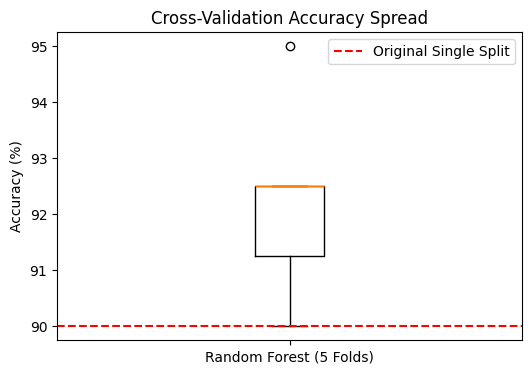

In [5]:
plt.figure(figsize=(6, 4))
plt.boxplot(cv_scores * 100)
plt.title("Cross-Validation Accuracy Spread")
plt.ylabel("Accuracy (%)")
plt.xticks([1], ["Random Forest (5 Folds)"])
plt.axhline(single_split_acc * 100, color='red', linestyle='--', label='Original Single Split')
plt.legend()
plt.show()

# Interpretation: If the box is very tall (high standard deviation), the model is volatile 
# and might not be trustworthy in production alerting systems.

### 5. Naming Stratified K-Fold Explicitly
In infrastructure, outages are rare — a small minority class buried in a sea of "Healthy" samples. If a fold randomly ended up with very few (or zero) failure examples, that fold's score would be unreliable, and averages across folds could be skewed.

Here's the twist: the `cross_val_score(model, X, y, cv=5, ...)` call in Section 3 was **already** using stratified folds. When you pass a plain integer for `cv` on a classification problem, scikit-learn's `cross_val_score` defaults to `StratifiedKFold` automatically — it's built in, not something you have to opt into.

Below we just construct that same `StratifiedKFold` object **explicitly** and pass it in by name. That's exactly why the average accuracy is identical (92.25%) to Section 3 — we haven't changed the cross-validation behavior at all. What we've gained is naming the mechanism and exposing knobs (`shuffle`, `random_state`, `n_splits`) that the integer shorthand doesn't. Being explicit still matters: it makes the stratification visible to a reader, and it's required the moment you need a fold strategy `cv=int` doesn't cover (e.g. `GroupKFold`, `TimeSeriesSplit`, or a custom `shuffle`/`random_state`).

In [6]:
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
stratified_cv_scores = cross_val_score(model, X, y, cv=stratified_kfold, scoring='accuracy')

print("Stratified Average Accuracy: {:.2f}%".format(stratified_cv_scores.mean() * 100))

# Always default to Stratified K-Fold when dealing with heavily imbalanced SRE logs!

Stratified Average Accuracy: 92.25%


### Summary
- A single train/test split gives you one accuracy number that depends heavily on which rows happened to land in the test set; K-Fold Cross-Validation gives a **more reliable estimate** by averaging performance over `K` different splits and reporting the spread (standard deviation) alongside the mean.
- On this dataset, cross-validation (92.25% average, ±1.66%) told a more trustworthy story than the single 90.00% split — not because the numbers were wildly different here, but because we now know how much they *could* vary.
- **Stratification** — keeping the ratio of Healthy vs. Failure consistent across every fold — matters most when the target is imbalanced, which is the normal case for SRE outage/alert data. `cross_val_score` already stratifies by default for classifiers when `cv` is an integer; use an explicit `StratifiedKFold` when you need to control `shuffle`, `random_state`, or swap in a different splitting strategy entirely.
- Rule of thumb: use cross-validation (not a single split) whenever you're choosing between models or tuning hyperparameters, and reserve a completely untouched holdout set for the final, one-time evaluation before shipping.